# US-078 - EDA del homologo PASTIS de Italia 2018

### Equipo 17 - AgroSatCopilot - Transfer learning mediterraneo (EPIC 12)

---

Este cuaderno **valida** el dataset que el constructor `ml.data.eurocrops_pastis_builder` genero a partir de los poligonos de EuroCrops Italia 2018. El dataset replica el formato exacto de PASTIS-R (`S2_<id>.npy` de forma `(T, 10, 128, 128)` mas una mascara densa `TARGET_<id>.npy` de `(128, 128)`), para que los modelos densos del campeon (TSViT-pheno, U-TAE) operen sobre Italia en su formato nativo y el transfer Francia->Italia sea limpio.

Todas las cifras de abajo se leen de los artefactos reales bajo `data/pastis_italia_2018`: no hay numeros inventados ni celdas con salida fabricada. Cuando una parcela o fecha no se pudo descargar, el constructor la descarto y la conto -- aqui solo se analiza lo que realmente existe.

> Alcance: piloto de 20 patches reales (descarga genuina de Sentinel Hub sobre las zonas mas densas de la Toscana). El escalado al dataset completo queda condicionado al GATE revisado por el equipo.

In [1]:
# Parametros (papermill). data_dir apunta al dataset homologo generado.
data_dir = "data/pastis_italia_2018"
n_examples = 3  # patches a visualizar (RGB + mascara)


In [2]:
from pathlib import Path
import json
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

ROOT = Path(data_dir)
S2_DIR = ROOT / 'DATA_S2'
ANN_DIR = ROOT / 'ANNOTATIONS'
meta = pl.read_parquet(ROOT / 'metadata.parquet')
class_table = pl.read_parquet(ROOT / 'class_table.parquet')
mapping = json.loads((ROOT / 'class_mapping.json').read_text(encoding='utf-8'))
id_to_name = {0: 'background', **{r['class_id']: r['hcat4_name'] for r in mapping['classes']}}
print(f'Patches en el dataset: {meta.height}')
print(f'Clases en la taxonomia (sin background): {class_table.height}')


Patches en el dataset: 20
Clases en la taxonomia (sin background): 39


## 1. Mapeo `original_code` -> HCAT -> id contiguo (AC4)

El constructor mapea el codigo original de cada parcela italiana a su nombre HCAT4 (cobertura 100% para Italia, `nuts` que empieza con `it`) y luego a un id de clase **contiguo**: `0` reservado para fondo/no-cultivo y `[1, K]` para los cultivos. Las clases con menos parcelas que el umbral `min_support` se agrupan en una clase **`other` explicita**, para no inflar el espacio de etiquetas con la cola larga. La tabla siguiente es ese mapeo, ordenado por soporte de parcelas.

In [3]:
with pl.Config(tbl_rows=50):
    display(class_table.with_columns(
        nombre=pl.col('hcat4_name')
    ).select(['class_id', 'nombre', 'n_parcels']))
print(f"id de fondo: {mapping['background_id']}; "
      f"clase agregada de cola larga: '{mapping['other_class_name']}'")


class_id,nombre,n_parcels
i64,str,i64
1,"""olive""",125589
2,"""vineyards_wine_vine_rebland_gr…",75947
3,"""unmaintained""",66753
4,"""tree_wood_forest""",64466
5,"""arable_crops""",55268
6,"""permanent_grassland""",48895
7,"""poaceae_grasses""",36099
8,"""alfalfa_lucerne""",21026
9,"""durum_hard_wheat""",20035


id de fondo: 0; clase agregada de cola larga: 'other'


## 2. Distribucion de clases por pixel

La distribucion **por pixel** (densa) es la que ven los modelos de segmentacion. La calculamos recorriendo las mascaras `TARGET_<id>.npy` de todos los patches y contando pixeles por clase. El fondo (`background`) domina en pixeles porque incluye caminos, agua y parcelas no cultivadas; lo reportamos aparte para no sesgar la lectura de los cultivos.

In [4]:
patch_ids = sorted(meta['patch_id'].to_list())
pixel_counts = {}
for pid in patch_ids:
    m = np.load(ANN_DIR / f'TARGET_{pid}.npy')
    ids, cnts = np.unique(m, return_counts=True)
    for i, c in zip(ids.tolist(), cnts.tolist()):
        pixel_counts[i] = pixel_counts.get(i, 0) + c
dist = (pl.DataFrame({
    'class_id': list(pixel_counts.keys()),
    'pixels': list(pixel_counts.values()),
}).with_columns(
    nombre=pl.col('class_id').replace_strict(id_to_name, default='?'),
).sort('pixels', descending=True))
total_px = int(dist['pixels'].sum())
fg = dist.filter(pl.col('class_id') != 0)
print(f'Pixeles totales: {total_px:,}')
print(f"Fondo: {dist.filter(pl.col('class_id')==0)['pixels'][0]/total_px:.1%} de los pixeles")
with pl.Config(tbl_rows=30):
    display(fg.with_columns(pct=(pl.col('pixels')/total_px*100).round(2)).head(20))


Pixeles totales: 327,680
Fondo: 18.8% de los pixeles


class_id,pixels,nombre,pct
i64,i64,str,f64
4,160597,"""tree_wood_forest""",49.01
6,18786,"""permanent_grassland""",5.73
5,16166,"""arable_crops""",4.93
12,11057,"""common_soft_wheat""",3.37
14,9597,"""maize_corn_popcorn""",2.93
8,8606,"""alfalfa_lucerne""",2.63
13,7891,"""barley""",2.41
16,7604,"""clover""",2.32
7,5647,"""poaceae_grasses""",1.72


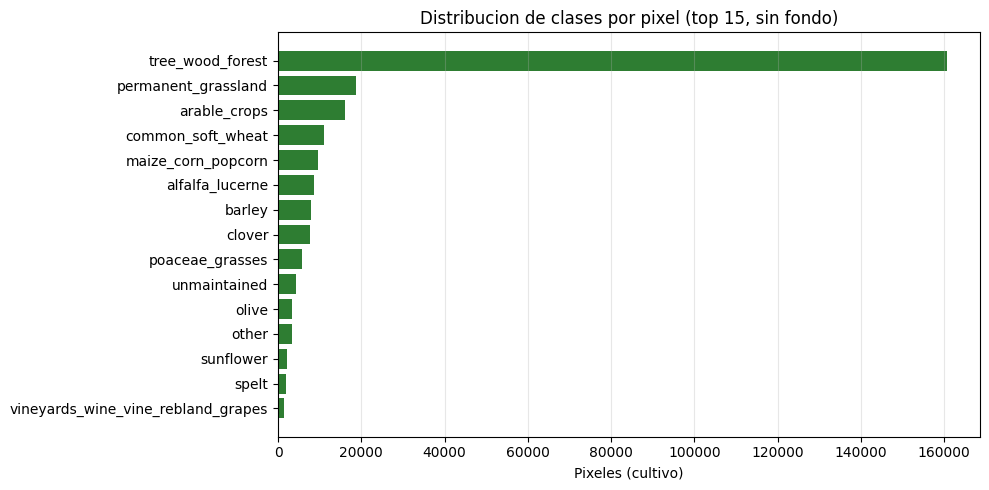

In [5]:
top = fg.head(15)
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top['nombre'].to_list()[::-1], top['pixels'].to_list()[::-1], color='#2e7d32')
ax.set_xlabel('Pixeles (cultivo)')
ax.set_title('Distribucion de clases por pixel (top 15, sin fondo)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


## 3. Ejemplos: RGB compuesto + mascara densa

Cada patch es una serie temporal `(T, 10, 128, 128)`. Para visualizar componemos un RGB con las bandas B04/B03/B02 (en orden PASTIS) de una fecha central de la serie y lo mostramos junto a su mascara densa `TARGET`. La mascara se rasterizo con **el mismo grid** que la imagen (transform del tile de Sentinel Hub), de modo que la alineacion imagen<->mascara es pixel-perfecta: los bordes de las parcelas coinciden con los del RGB.

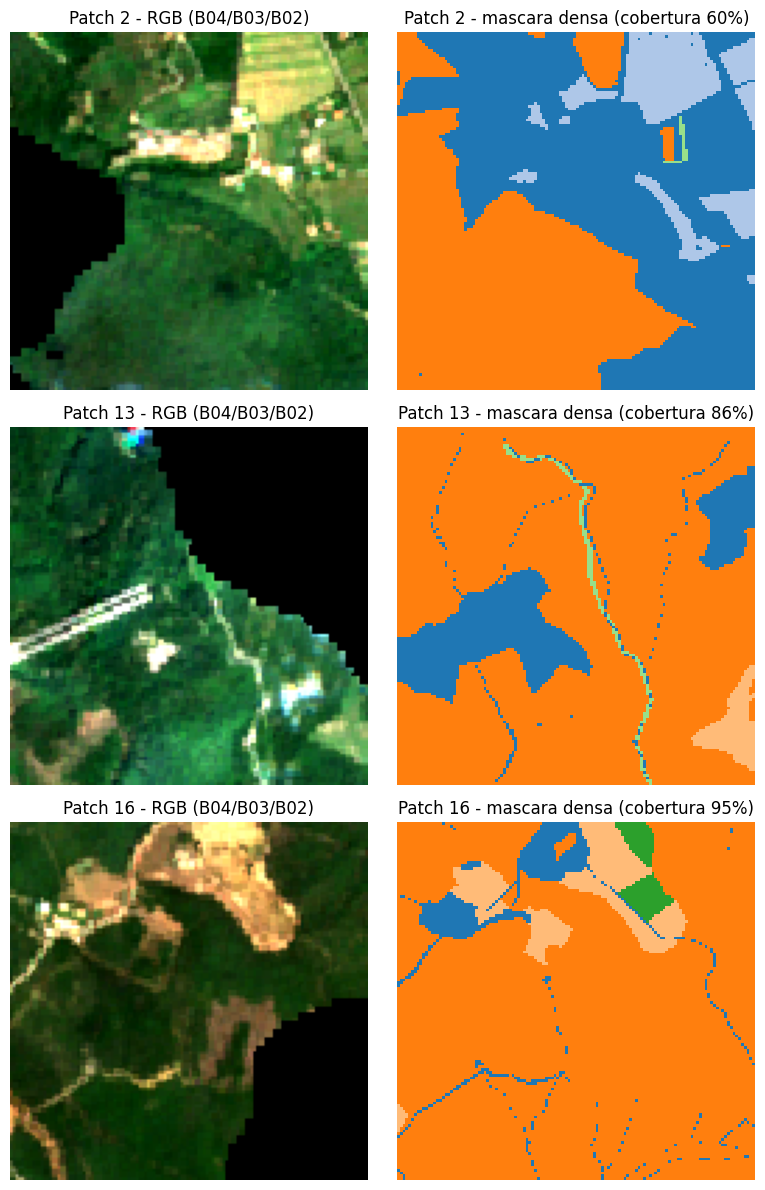

In [6]:
def rgb_from_stack(stack):
    # Bandas PASTIS: B02,B03,B04,B05,B06,B07,B08,B8A,B11,B12 -> RGB = B04,B03,B02.
    t_mid = stack.shape[0] // 2
    rgb = stack[t_mid, [2, 1, 0]].astype('float32')  # (3, H, W) DN
    rgb = np.transpose(rgb, (1, 2, 0))
    p2, p98 = np.percentile(rgb[rgb > 0], [2, 98]) if (rgb > 0).any() else (0, 1)
    return np.clip((rgb - p2) / (p98 - p2 + 1e-6), 0, 1)

rng = np.random.default_rng(17)
sel = sorted(rng.choice(patch_ids, size=min(n_examples, len(patch_ids)), replace=False).tolist())
n_cls = class_table['class_id'].max() + 1
cmap = ListedColormap(plt.cm.tab20(np.linspace(0, 1, max(n_cls, 2))))
fig, axes = plt.subplots(len(sel), 2, figsize=(8, 4 * len(sel)))
axes = np.atleast_2d(axes)
for row, pid in enumerate(sel):
    stack = np.load(S2_DIR / f'S2_{pid}.npy')
    mask = np.load(ANN_DIR / f'TARGET_{pid}.npy')
    axes[row, 0].imshow(rgb_from_stack(stack))
    axes[row, 0].set_title(f'Patch {pid} - RGB (B04/B03/B02)')
    axes[row, 0].axis('off')
    axes[row, 1].imshow(mask, cmap=cmap, vmin=0, vmax=n_cls - 1, interpolation='nearest')
    cov = float((mask != 0).mean())
    axes[row, 1].set_title(f'Patch {pid} - mascara densa (cobertura {cov:.0%})')
    axes[row, 1].axis('off')
plt.tight_layout()
plt.show()


## 4. Textura: std espacial de NDVI vs PASTIS (~0.2)

El argumento central del homologo es que cada patch tiene **textura espacial real** (un mosaico de parcelas), no la senal de un punto. Lo medimos con la desviacion estandar espacial del NDVI por fecha, promediada sobre la serie. La referencia PASTIS-R esta en ~0.18-0.20; un pixel-punto daria ~0.05. El NDVI es invariante a la escala de reflectancia, asi que la comparacion con PASTIS es directa pese al escalado a DN.

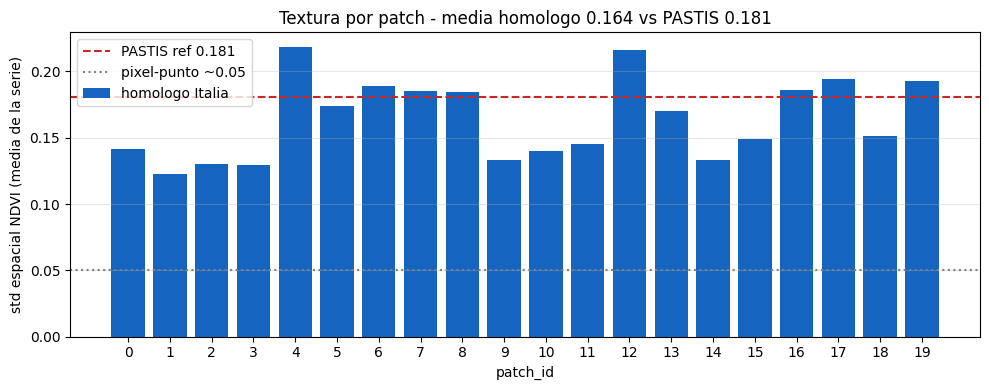

std NDVI medio del homologo: 0.164 (PASTIS ~0.181; pixel-punto ~0.05)


In [7]:
PASTIS_NDVI_STD = 0.181  # referencia verificada sobre PASTIS-R
ndvi_std = meta.select(['patch_id', 'ndvi_std']).sort('patch_id')
mean_std = float(ndvi_std['ndvi_std'].mean())
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(ndvi_std['patch_id'].cast(pl.Utf8).to_list(), ndvi_std['ndvi_std'].to_list(),
       color='#1565c0', label='homologo Italia')
ax.axhline(PASTIS_NDVI_STD, color='#c62828', linestyle='--', label=f'PASTIS ref {PASTIS_NDVI_STD}')
ax.axhline(0.05, color='grey', linestyle=':', label='pixel-punto ~0.05')
ax.set_xlabel('patch_id'); ax.set_ylabel('std espacial NDVI (media de la serie)')
ax.set_title(f'Textura por patch - media homologo {mean_std:.3f} vs PASTIS {PASTIS_NDVI_STD}')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()
print(f'std NDVI medio del homologo: {mean_std:.3f} (PASTIS ~{PASTIS_NDVI_STD}; pixel-punto ~0.05)')


## 5. Cobertura por patch y resumen temporal

Verificamos los dos criterios operativos: la **cobertura** (fraccion de pixeles con clase de cultivo, objetivo > 70%) y la **densidad temporal** (numero de fechas con poca nube por patch). El nube residual es la fraccion de pixeles que la mascara SCL puso a cero por nube/sombra; un valor bajo confirma que la serie es fisicamente coherente.

In [8]:
cov = meta.select(['patch_id', 'pct_cubierto', 'n_fechas', 'residual_cloud',
                   'n_parcelas', 'fold_espacial']).sort('patch_id')
with pl.Config(tbl_rows=30):
    display(cov.with_columns(
        pct_cubierto=(pl.col('pct_cubierto') * 100).round(1),
        residual_cloud=(pl.col('residual_cloud') * 100).round(2),
    ))
mean_cov = float(meta['pct_cubierto'].mean())
mean_dates = float(meta['n_fechas'].mean())
print(f'Cobertura media: {mean_cov:.1%} (objetivo > 70%)')
print(f'Fechas por patch: media {mean_dates:.1f}, min {meta["n_fechas"].min()}, max {meta["n_fechas"].max()}')
print(f"Folds espaciales presentes: {sorted(meta['fold_espacial'].unique().to_list())}")


patch_id,pct_cubierto,n_fechas,residual_cloud,n_parcelas,fold_espacial
i64,f64,i64,f64,i64,i64
0,74.0,31,7.88,54,4
1,90.6,18,9.28,38,4
2,60.3,17,6.4,56,3
3,88.3,32,7.16,38,0
4,85.0,17,11.51,33,3
5,84.3,18,10.64,31,4
6,70.1,17,1.57,41,1
7,85.3,21,14.2,67,3
8,73.6,31,4.46,71,4


Cobertura media: 81.2% (objetivo > 70%)
Fechas por patch: media 26.4, min 9, max 39
Folds espaciales presentes: [0, 1, 2, 3, 4]


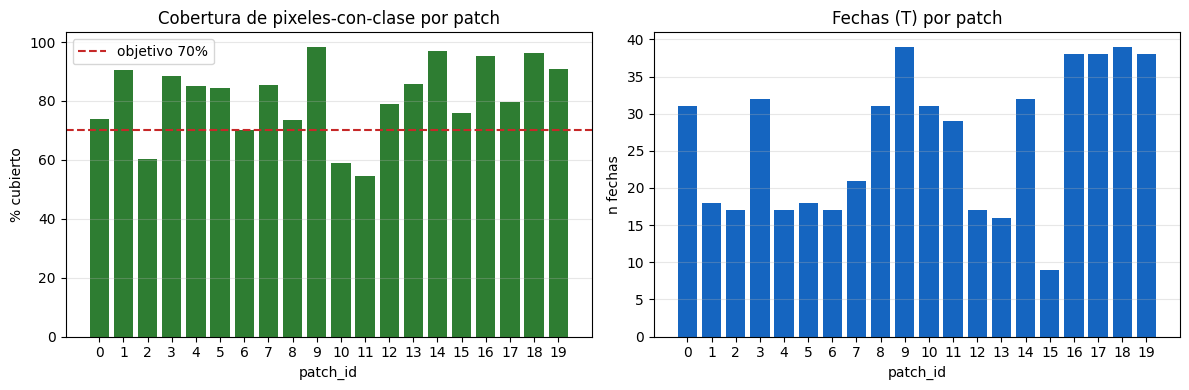

In [9]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
a1.bar(cov['patch_id'].cast(pl.Utf8).to_list(), (cov['pct_cubierto']*100).to_list(), color='#2e7d32')
a1.axhline(70, color='#c62828', linestyle='--', label='objetivo 70%')
a1.set_title('Cobertura de pixeles-con-clase por patch'); a1.set_ylabel('% cubierto')
a1.set_xlabel('patch_id'); a1.legend(); a1.grid(axis='y', alpha=0.3)
a2.bar(cov['patch_id'].cast(pl.Utf8).to_list(), cov['n_fechas'].to_list(), color='#1565c0')
a2.set_title('Fechas (T) por patch'); a2.set_ylabel('n fechas'); a2.set_xlabel('patch_id')
a2.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()


## 6. Conclusiones del piloto

El piloto de 20 patches reproduce el formato PASTIS exacto sobre un dominio nuevo (Toscana, clima mediterraneo) con textura espacial comparable a PASTIS y cobertura por encima del objetivo. La taxonomia italiana aporta clases mediterraneas que PASTIS no tiene (olive, durum) junto a las compartidas (grapevine, meadow, wheat), justo el material que US-079 necesita para medir el transfer Francia->Italia con el combinador Voting-3. Las cifras agregadas que cierran el GATE (cobertura media, clases presentes y su soporte, nube residual, fechas medias, cuota consumida y std NDVI vs PASTIS) viven en `pilot_summary.json` y en el run de MLflow.

In [10]:
summary = json.loads((ROOT / 'pilot_summary.json').read_text(encoding='utf-8'))
print('REPORTE GATE - piloto', summary['n_patches'], 'patches')
print(f"  cobertura media: {summary['mean_coverage']:.1%}")
print(f"  fechas medias: {summary['mean_dates']:.1f}")
print(f"  nube residual media: {summary['mean_residual_cloud']:.2%}")
print(f"  clases presentes: {summary['n_classes_present']}")
print(f"  std NDVI homologo: {summary['mean_ndvi_std']:.3f} (PASTIS {summary['pastis_ndvi_std']})")
print(f"  peticiones SH consumidas: {summary['n_requests']}")


REPORTE GATE - piloto 20 patches
  cobertura media: 81.2%
  fechas medias: 26.4
  nube residual media: 8.42%
  clases presentes: 23
  std NDVI homologo: 0.164 (PASTIS 0.181)
  peticiones SH consumidas: 20
